In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import seaborn as sns
import mosek
import matplotlib.pyplot as plt
import datetime as date
from datetime import datetime as dt
from dateutil.relativedelta import *
from scipy.stats import rankdata

In [2]:
################ all h functions evaluation

def h_quad(x,par):
    return((1+par)*x-par*x**2)

def h_single_power(x,par):
    return(1-(np.abs(1-x))**par)

def h_double_power(x,par):
    return((1-(np.abs(1-x))**par)**(1/par))

def h_pow(x,par):
    return(x**par)

def h_logarithm(x,par):
    return(x**par*(1-np.log(x**r)))


In [3]:
################ all phi functions constraints

def modified_chi2(p,q,r,par,constraints):
    N = p.shape[0]
    phi_cons = 0
    for i in range(N):
        phi_cons = phi_cons + 1/p[i]*(q[i]-p[i])**2
    constraints.append(phi_cons<=r)
    return(constraints)

def kullback_leibler(p,q,r,par,constraints):
    N = p.shape[0]
    phi_cons = 0
    for i in range(N):
        phi_cons = phi_cons -cp.entr(q[i]) - q[i]*np.log(p[i])
    constraints.append(phi_cons<=r)
    return(constraints)

In [4]:
############### all h functions constraints

def h_quadratic(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        v = (1+par)*cp.sum(q[rank[0:i+1]])-par*cp.sum(q[rank[0:i+1]])**2
        constraints.append(cp.sum(q_b[rank[0:i+1]])-v <= 0)
    return(constraints)

def h_sing_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        v = 1-cp.power((1-cp.sum(q[rank[0:i+1]])),par)
        constraints.append(cp.sum(q_b[rank[0:i+1]])-v <= 0)
    return(constraints)

def h_doub_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    u1 = cp.Variable(N, nonneg = True)
    u2 = cp.Variable(N, nonneg = True)
    t = cp.Variable(N)
    constraints.append(u1<=1)
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])+t[i]<=0)
        constraints.extend((u2[i]>=-t[i],u1[i]>= 1-cp.sum(q[rank[0:i+1]])))
        constraints.append(cp.power(u1[i],par)+cp.power(u2[i],par) <= 1)
    return(constraints)

def h_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])-cp.power(cp.sum(q[rank[0:i+1]]),par) <= 0)
    return(constraints)

def h_log(q_b,q,rank,par,constraints):
    N = q.shape[0]
    u1 = cp.Variable(N, nonneg = True)
    t = cp.Variable(N)
    constraints.append(u1<=1)
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])+t[i]<=0)
        constraints.append(-u1[i]-cp.entr(u1[i])<= t[i])
        constraints.append(u1[i]-cp.power(cp.sum(q[rank[0:i+1]]),par) <= 0)
    return(constraints)

In [5]:
############## all phi conjugates

def modified_chi2_conj(gamma, s,t, constraints):
    N = s.shape[0]
    w = cp.Variable(N, nonneg = True)
    for i in range(N):
        constraints.append(cp.norm(cp.vstack([w[i],t[i]/2]))<=(t[i]+2*gamma)/2)
    constraints.append(s/2+gamma*(np.zeros(N)+1)<= w)
    return(constraints)

def kullback_leibler_conj(gamma,s,t,constraints):
    N = s.shape[0]
    w = cp.Variable(N)
    constraints.append(w - gamma*(np.zeros(N)+1) <= t)
    for i in range(N):
        constraints.append(cp.kl_div(gamma,w[i])+gamma+s[i]-w[i]<= 0)
    return(constraints)

In [6]:
############## all h conjugates

def h_quad_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    eta = cp.Variable(M, nonneg= True)
    for j in range(M):
        constraints.append(cp.norm(cp.vstack([eta[j],(z[j]-lbda[j])/2]))<=(z[j]+lbda[j])/2)
        constraints.append(1/(2*np.sqrt(par))*(-v[j]+lbda[j]+par*lbda[j])<= eta[j])
    return(constraints)

def h_sing_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    xi_4 = cp.Variable(M, nonneg = True)
    constraints.extend((xi_3 <= xi_2, xi_3 <= v))
    constraints.append(lbda-xi_3+(par**(-1/(par-1))-par**(-par/(par-1)))*xi_4 <= z)
    exponent = np.array([(par-1)/par,1-(par-1)/par])
    for j in range(M):
        constraints.append(xi_2[j]-cp.geo_mean(cp.vstack([xi_4[j],lbda[j]]),exponent)<= 0)
    return(constraints)

def h_doub_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    constraints.extend((xi_2 >= lbda, -v + xi_3 <=0))
    exp = par/(par-1)
    for j in range(M):
        constraints.append(-xi_3[j]+cp.pnorm(cp.vstack([xi_2[j],xi_3[j]]),exp)<= z[j])
    return(constraints)

def h_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    constraints.append(v >= 0)
    const = (par**(par/(1-par))-par**(1/(1-par)))**(1-par)
    exp = np.array([1-par, par])
    for j in range(M):
        constraints.append(cp.geo_mean(cp.vstack([z[j],v[j]]),exp)>= lbda[j]*const)
    return(constraints)

def h_log_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_1 = cp.Variable(M, nonneg = True)
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    xi_4 = cp.Variable(M, nonneg = True)
    const = (par**(par/(1-par))-par**(1/(1-par)))
    constraints.extend((v >= 0, xi_3 + xi_1 + const* xi_4 <= z))
    exp = np.array([par, 1-par])
    for j in range(M):
        constraints.append(xi_2[j]+xi_3[j] >= cp.kl_div(lbda[j],xi_1[j]) +lbda[j]-xi_1[j])
        constraints.append(xi_2[j] <= cp.geo_mean(cp.vstack([v[j],xi_4[j]]),exp))
    return(constraints)
    

In [7]:
############### all utility functions

def lin_utility(R,a,r_f,par):
    return(R@a + (1-cp.sum(a))*r_f)

def lin_utility_eva(R,a,r_f,par):
    return(R.dot(a)+(1-sum(a))*r_f)
    

In [8]:
############## all set operations

def ranktoset (A):
    A = list(A)
    sets = [[A[0]]]
    for i in range(1,len(A)):
        new = A[0:i+1]
        sets.append(new)
    return(sets)

def makesetflex (A, B):    # we assume A is non-empty
    N = len(A)
    B = list(B)
    M = len(B)
    added = []
    for i in range(M):
        new = B[0:i+1]
        for k in range(N):
            if len(A[k])==len(new) and len(np.intersect1d(A[k],new))==len(new):
                break
            if k == N-1:
                A.append(new)
                added.append(new)
    return(A,added)

In [9]:
############### robust_counterpart and robustness check


def robust_counterpart(sets,p,R,r,par,r_f,c,phi_conj, h_conj,utility):
    N = len(p)
    I = len(R[0])
    M = len(sets)
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    a = cp.Variable(I)
    alpha = cp.Variable(1)
    beta = cp.Variable(1)
    gamma = cp.Variable(1,nonneg = True)
    t = cp.Variable(N)
    z = cp.Variable(M)
    s = cp.Variable(N)
    constraints = [cp.abs(a)<= 10]
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-utility(R,a,r_f,par)[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,s,t,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)
    
def robustcheck(a,R,r,p,par,r_f,h_func, phi_func,utility, utility_eva):
    N = len(p)
    x = -utility_eva(R,a,r_f,par)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    q = cp.Variable(N, nonneg=True)
    constraints = [cp.sum(q) == 1, cp.sum(q_b)==1]
    constraints = h_func(q_b,q,rank,par,constraints)
    constraints = phi_func(p,q,r,par,constraints)
    obj = cp.Maximize(-q_b.T @ utility(R,a,r_f,par))
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value)



In [10]:
################### final algorithm

def squeeze_algorithm(R,r,c,p,par,r_f,h_eva, phi_func,h_func,phi_conj,h_conj,utility):
    N = len(p)
    I = len(R[0])
    a = cp.Variable(I)
    constraints = [cp.abs(a)<=10]
    h = np.zeros(N)
    iterations = 0
    steps = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    w = a.value
    upperobj = prob.value
    nonstop = True
    while nonstop:
        [rbvalue,h] = robustcheck(w,R,r,p,par,r_f,h_func,phi_func,utility,utility_eva)
        print('rbvalue',rbvalue)
        if rbvalue <= c+1e-3:
            oldrank = np.argsort(R.dot(w))
            sets = ranktoset(oldrank)
            while nonstop:
                [w,lowerobj] = robust_counterpart(sets,p,R,r,par,r_f,c,phi_conj,h_conj,utility)
                newrank = np.argsort(R.dot(w))
                if np.array_equal(newrank,oldrank):
                    break
                [sets,added] = makesetflex(sets,newrank)
                oldrank = newrank
                steps = steps + 1
            return(w,'upperbound', upperobj, 'lowerbound', lowerobj, 'cut-iterations', iterations,' robust iterations' ,steps)
        constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = a.value
        upperobj = prob.value
        print('cut-iterations', iterations)

In [11]:
def non_robust_cut_check(a,R,p,par,r_f, utility_eva, utility, h_func):
    N = len(p)
    x = -utility_eva(R,a,r_f,par)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    constraints = [cp.sum(q_b)==1]
    constraints = h_func(q_b,p,rank,par,constraints)
    obj = cp.Maximize(-q_b.T @ utility(R,a,r_f,par))
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value)


def non_robust_cut(R,c,p,par,r_f, h_eva,h_func, utility, utility_eva):
    N = len(p)
    I = len(R[0])
    a = cp.Variable(I)
    constraints = [cp.abs(a)<=10]
    h = np.zeros(N)
    iterations = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    upperobj = prob.value
    w = a.value
    nonstop = True
    while nonstop:
        [rbvalue,h] = non_robust_cut_check(w,R,p,par,r_f, utility_eva, utility, h_func)
        print('rbvalue',rbvalue)
        if rbvalue <= c +1e-3:
            return(w,'upperbound', upperobj, 'cut-iterations', iterations)
        constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = a.value
        upperobj = prob.value
        print('cut-iterations', iterations)

In [12]:
def Ex_return(q,R,w,r_f,par,utility_eva):
    x = utility_eva(R,w,r_f,par)
    ret = q.dot(x)
    return(ret)

def risk_calc(q,R,w,r_f,par,utility_eva, h_eva):
    N = len(q)
    x = -utility_eva(R,w,r_f,par)
    rank = np.argsort((-x))
    h = np.zeros(N)
    risk = h_eva(q[rank[0]],par)*x[rank[0]]
    for i in range(1,N-1):
        weight = h_eva(sum(q[rank[0:i+1]]),par)-h_eva(sum(q[rank[0:i]]),par)
        risk = risk + weight*x[rank[i]]
    weight = 1-h_eva(sum(q[rank[0:N-1]]),par)
    risk = risk + weight*x[rank[N-1]]
    return(risk)

In [13]:
df_returns6 = pd.read_csv('6_Portfolios_2x3.csv', skiprows = 15)

In [14]:
df_returns = df_returns6[0:1144].copy()
df_returns['Date'] = pd.to_datetime(df_returns['Date'], format = '%Y%m')
for i in range(1, len(df_returns.columns)):
    df_returns[df_returns.columns[i]] = pd.to_numeric(df_returns[df_returns.columns[i]])
df_returns

,Date,SMALL LoBM,ME1 BM2,SMALL HiBM,BIG LoBM,ME2 BM2,BIG HiBM
0,1926-07-01,1.0874,0.9349,-0.0695,5.7168,1.9620,1.4222
1,1926-08-01,0.7030,1.2300,5.3842,2.7154,2.6930,6.3154
2,1926-09-01,-2.9117,-0.1303,-0.4374,1.4287,0.0704,-0.7967
3,1926-10-01,-3.8196,-4.5860,-2.0112,-3.5898,-2.3398,-4.0970
4,1926-11-01,3.1806,3.7233,2.0944,3.1292,2.8952,3.4614
...,...,...,...,...,...,...,...
1139,2021-06-01,5.6058,0.4400,-1.0979,4.8188,-1.2594,-4.0036
1140,2021-07-01,-5.5593,-1.8623,-3.6521,3.1048,-0.0099,-2.3000
1141,2021-08-01,2.3903,1.5124,2.6680,3.5667,1.4122,3.0371
1142,2021-09-01,-4.3421,-3.4661,0.6445,-5.4525,-3.8570,-0.2526


In [15]:
startdate = dt(1984,1,3)
enddate = dt(2014,1,3)
X = df_returns[np.logical_and(df_returns.Date >= startdate, df_returns.Date <= enddate )][df_returns.columns[1:7]]
X = X.reset_index(drop = True)
R = X.to_numpy()

In [16]:
N=R.shape[0]
p = np.zeros(N)+1/N
I = R.shape[1]
par = 2
r = 0.3   # this is the parameter of the h function min(1, p/(1-m))
r_f = 0.07
c = 10
h_eva = h_double_power
phi_func = kullback_leibler
h_func = h_doub_power
phi_conj = kullback_leibler_conj
h_conj = h_doub_power_conj
utility= lin_utility
utility_eva = lin_utility_eva

In [17]:
robust_result = squeeze_algorithm(R,r,c,p,par,r_f,h_eva, phi_func,h_func,phi_conj,h_conj,utility)
print(robust_result)
w_rob = robust_result[0]

rbvalue 820.1868121947991
cut-iterations 1
rbvalue 180.7512077238614
cut-iterations 2
rbvalue 98.32400527391762
cut-iterations 3
rbvalue 64.87735953914819
cut-iterations 4
rbvalue 27.89617617059654
cut-iterations 5
rbvalue 46.37057656227827
cut-iterations 6
rbvalue 44.88316059019625
cut-iterations 7
rbvalue 21.414035159417175
cut-iterations 8
rbvalue 23.051377815838563
cut-iterations 9
rbvalue 19.287960429669965
cut-iterations 10
rbvalue 15.610064226416814
cut-iterations 11
rbvalue 16.135701437017644
cut-iterations 12
rbvalue 14.181787179616885
cut-iterations 13
rbvalue 12.862890112776341
cut-iterations 14
rbvalue 12.014822092158997
cut-iterations 15
rbvalue 12.111910524729577
cut-iterations 16
rbvalue 11.803419576793386
cut-iterations 17
rbvalue 11.088420401418645
cut-iterations 18
rbvalue 11.192837847435491
cut-iterations 19
rbvalue 10.893828522606354
cut-iterations 20
rbvalue 10.630990289012324
cut-iterations 21
rbvalue 10.598535765282158
cut-iterations 22
rbvalue 10.388785918710068

In [18]:
results_nonrb = non_robust_cut(R,c,p,par,r_f, h_eva,h_func, utility, utility_eva)
print(results_nonrb)
w_notrob = results_nonrb[0]
robustcheck(results_nonrb[0],R,r,p,par,r_f,h_func, phi_func,utility, utility_eva)[0]

rbvalue 345.9922825738966
cut-iterations 1
rbvalue 43.05916402054321
cut-iterations 2
rbvalue 34.555771455137595
cut-iterations 3
rbvalue 22.065742727666283
cut-iterations 4
rbvalue 28.587873324697746
cut-iterations 5
rbvalue 16.411353255626942
cut-iterations 6
rbvalue 15.913965966808325
cut-iterations 7
rbvalue 16.577412842443596
cut-iterations 8
rbvalue 15.212550586243307
cut-iterations 9
rbvalue 12.152721583108605
cut-iterations 10
rbvalue 13.915683991901853
cut-iterations 11
rbvalue 12.635118266372334
cut-iterations 12
rbvalue 11.786586860534001
cut-iterations 13
rbvalue 11.14169309477333
cut-iterations 14
rbvalue 12.301123121902608
cut-iterations 15
rbvalue 10.7936165983518
cut-iterations 16
rbvalue 10.634736287653263
cut-iterations 17
rbvalue 10.408798433220026
cut-iterations 18
rbvalue 11.075574947970487
cut-iterations 19
rbvalue 10.331554749059887
cut-iterations 20
rbvalue 10.360170762167762
cut-iterations 21
rbvalue 10.198305714339636
cut-iterations 22
rbvalue 10.1972493725848

23.58244419345268

In [19]:
prob = []
N = R.shape[0]
mean = 1/N
var = np.sqrt(r/(N**2))
for i in range(5000):
    q_real = np.zeros(N)
    for j in range(N-1):
        continu = True
        while continu == True:
            q = np.random.normal(mean,var)
            if q>= 0:
                continu = False
                q_real[j] = q
    last = 1-np.sum(q_real[0:N-1])
    if last >= 0:
        q_real[N-1] = last
        prob.append(q_real)

In [21]:
risk_robust = np.zeros(len(prob))
risk_non_robust = np.zeros(len(prob))
Ex_ret_robust = np.zeros(len(prob))
Ex_ret_non_robust = np.zeros(len(prob))

for i in range(len(prob)):
    risk_robust[i] = risk_calc(prob[i],R,w_rob,r_f,par,utility_eva, h_eva)
    risk_non_robust[i] = risk_calc(prob[i],R,w_notrob,r_f,par,utility_eva, h_eva)
    Ex_ret_robust[i] = Ex_return(prob[i],R,w_rob,r_f,par,utility_eva)
    Ex_ret_non_robust[i] = Ex_return(prob[i],R,w_notrob,r_f,par,utility_eva)
    

In [263]:
N

360

In [20]:
len(prob)

328

<AxesSubplot:ylabel='Density'>

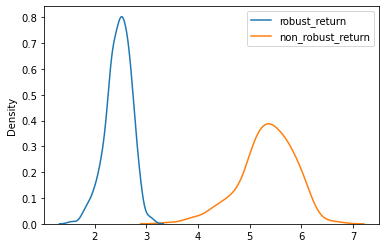

In [22]:
data1 = {'robust_return':Ex_ret_robust, 'non_robust_return':Ex_ret_non_robust}
dt1 = pd.DataFrame(data = data1)
sns.kdeplot(data = dt1)

<AxesSubplot:ylabel='Density'>

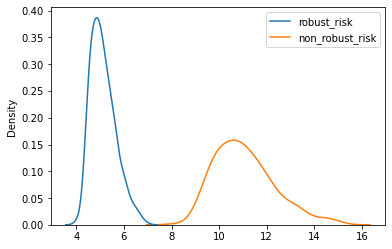

In [23]:
data2 = {'robust_risk':risk_robust, 'non_robust_risk':risk_non_robust}
dt2 = pd.DataFrame(data = data2)
sns.kdeplot(data = dt2)